In [126]:
# Import plotting libraries for visualizations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
# Import tools for splitting data and scaling features
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
 



## Section 2 – Load Data

**Dataset:** `student_performance.csv` — 1,000,000 student records with 6 columns.

**Columns:**
- `student_id` – just an ID, not useful for prediction
- `weekly_self_study_hours` – hours studied per week outside class
- `attendance_percentage` – how often the student showed up
- `class_participation` – engagement score from 0–10
- `total_score` – overall academic score
- `grade` – final letter grade (our target: A/B/C/D/F)


In [128]:

# Load the CSV file into a DataFrame
df = pd.read_csv("C:\\Users\\khana\\OneDrive - University of North Carolina at Charlotte\\Documents\\ds-studio-ii\\datasets\\student_performance.csv")

In [129]:
# the full dataset is 1 million rows which is really slow to train on
# so i'm taking a stratified sample of 50k rows
# stratified means each grade keeps its original proportion
# so we don't accidentally under-represent the rare grades like F
sampled = []
for grade, grp in df.groupby("grade"):
    n = max(1, int(50_000 * len(grp) / len(df)))
    sampled.append(grp.sample(min(len(grp), n), random_state=42))
df = pd.concat(sampled).reset_index(drop=True)

# The order of grades for consistent display
GRADE_ORDER = ["A", "B", "C", "D", "F"]
 
print(df.head())
print()
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Grade distribution:')
print(df['grade'].value_counts().reindex(GRADE_ORDER))

   student_id  weekly_self_study_hours  attendance_percentage  \
0       31116                     15.3                   86.1   
1      427908                     22.1                   66.2   
2      543490                     18.8                   70.9   
3      854786                     17.4                   81.1   
4      429844                     16.0                   90.3   

   class_participation  total_score grade  
0                 10.0         90.0     A  
1                  5.0        100.0     A  
2                  5.8         90.5     A  
3                  5.5        100.0     A  
4                  8.5         97.3     A  

Shape: (49998, 6)

Missing values:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Grade distribution:
grade
A    27432
B    12908
C     7099
D     2249
F      310
Name: count, dtype: int64


### EXPLORATORY DATA ANALYSIS (EDA)

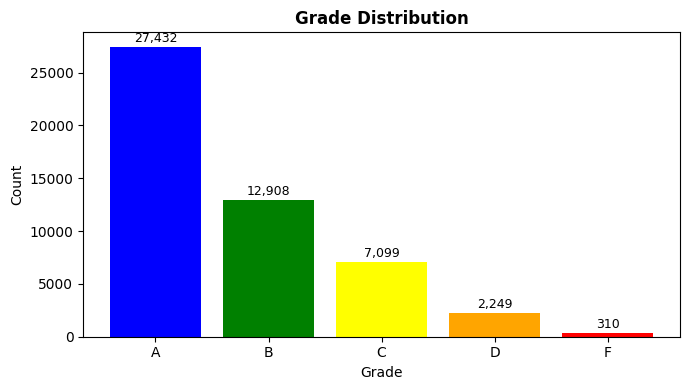

In [130]:
# first let's see how many students fall into each grade
# if one grade dominates it can mess with model training
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['grade'].value_counts().reindex(GRADE_ORDER)
ax.bar(counts.index, counts.values, color=PALETTE)
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Grade Distribution', fontweight='bold')
ax.set_xlabel('Grade'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**What I noticed:** There's a clear class imbalance. A grades dominate (~55%) while F grades are very rare (<1%). This is important because a model could just predict 'A' for everything and still get decent accuracy. I'll use `class_weight='balanced'` in the models to handle this.

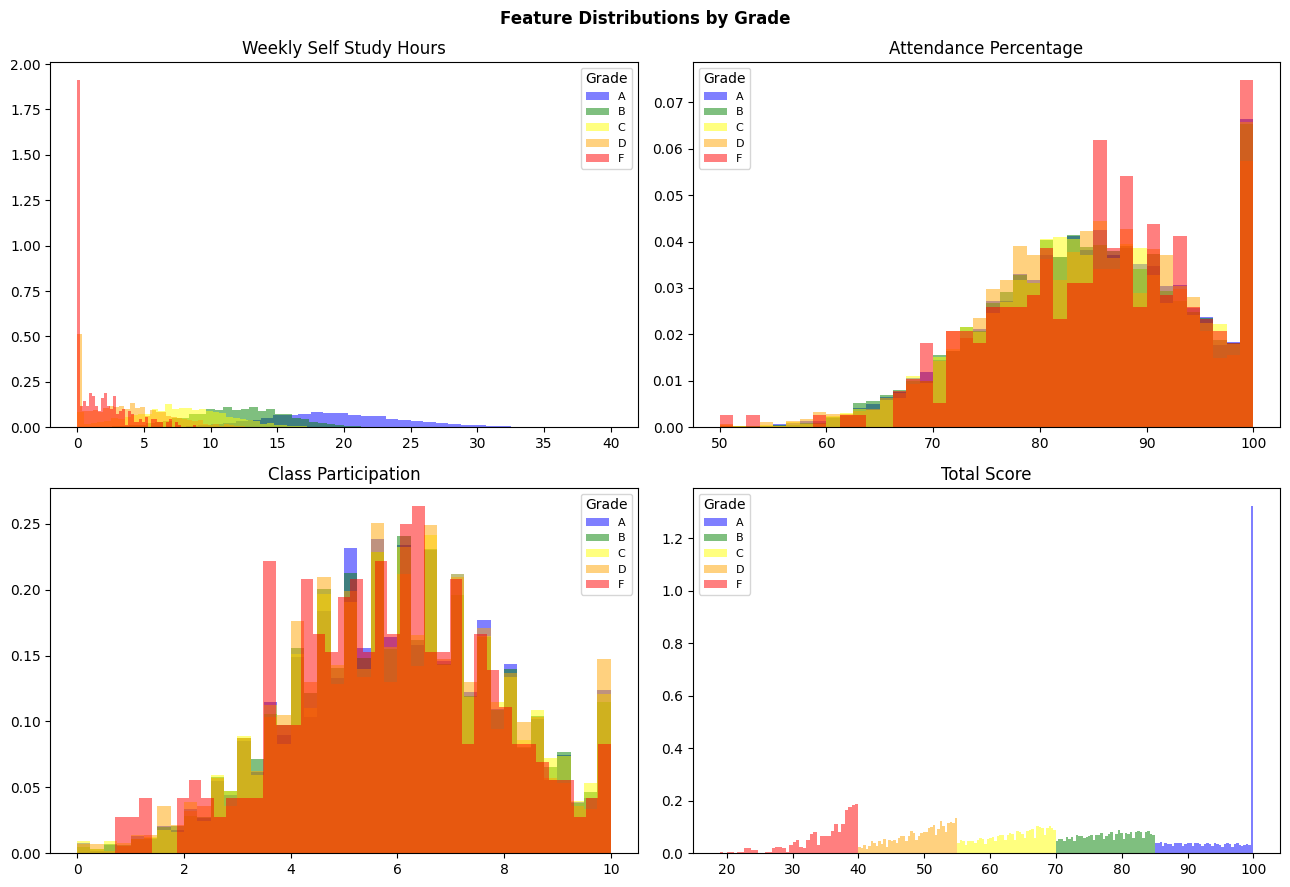

In [131]:
# looking at how each feature is distributed for each grade
# if the distributions clearly separate, the feature is useful for prediction
features = ['weekly_self_study_hours', 'attendance_percentage',
            'class_participation', 'total_score']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Feature Distributions by Grade', fontweight='bold')
for ax, feat in zip(axes.flat, features):
    for grade, color in zip(GRADE_ORDER, PALETTE):
        ax.hist(df[df['grade'] == grade][feat], bins=40, alpha=0.5,
                label=grade, color=color, density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(title='Grade', fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\khana\AppData\Local\Temp\ipykernel_32388\775927763.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grade', y=feat, order=GRADE_ORDER,
C:\Users\khana\AppData\Local\Temp\ipykernel_32388\775927763.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grade', y=feat, order=GRADE_ORDER,


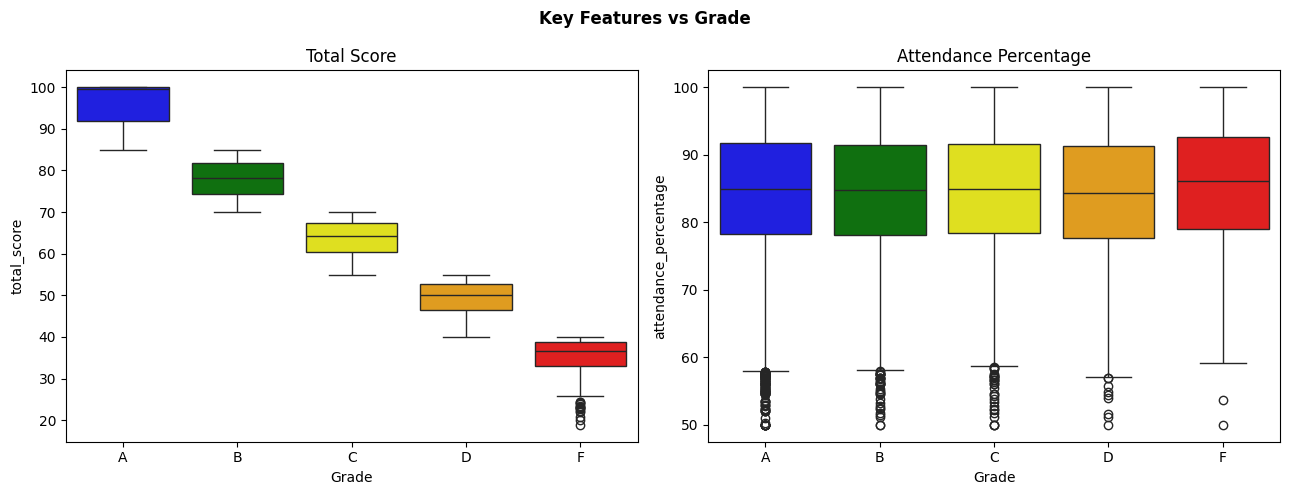

In [132]:
# boxplots to see the spread better, especially for total score and attendance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Key Features vs Grade', fontweight='bold')
for ax, feat in zip(axes, ['total_score', 'attendance_percentage']):
    sns.boxplot(data=df, x='grade', y=feat, order=GRADE_ORDER,
                palette=PALETTE, ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Grade')
plt.tight_layout()
plt.show()


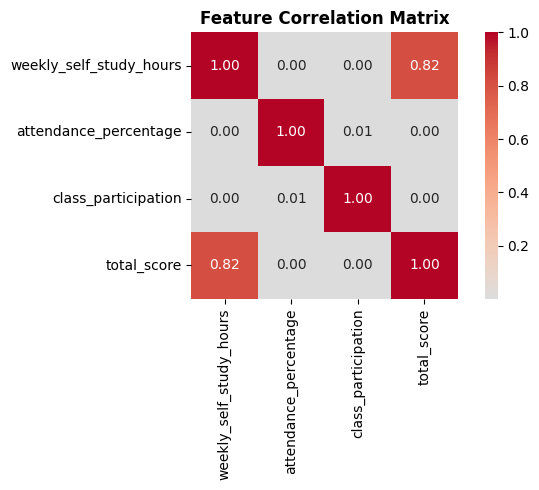

In [133]:
# checking correlations between features
# i want to make sure none of the features are basically the same thing
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
 

**What I noticed:** `total_score` has the clearest separation between grades which makes sense because grades are calculated from scores. The features aren't strongly correlated with each other so we're good to use all of them.

# PREPROCESSING

In [134]:
# dropping student_id because it's just an identifier, not useful for prediction
df = df.drop(columns=["student_id"])
 
# X is our input features, y is what we're trying to predict (grade)
X = df[features].copy()



In [135]:
# grades are letters so we need to convert them to numbers for the models
# using LabelEncoder and fitting it on our defined grade order so it's consistent
le = LabelEncoder()
le.fit(GRADE_ORDER)
y = le.transform(df["grade"])

# splitting into 80% training and 20% testing
# stratify=y makes sure both sets have the same grade proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [136]:
# scaling the features for Logistic Regression
# LR is sensitive to feature scale but tree-based models aren't
# so i only apply scaling to the LR inputs, not for Random Forest or AdaBoost
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
print(f"\nTrain size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Classes: {le.classes_}")



Train size: 39,998  |  Test size: 10,000
Classes: ['A' 'B' 'C' 'D' 'F']


# MODEL TRAINING

In [137]:
# i'm using three models to compare:
# Logistic Regression – simple baseline, easy to interpret
# Random Forest – handles non-linear patterns, gives feature importance
# AdaBoost – an ensemble method that combines weak learners
# i originally tried Gradient Boosting but it took way too long on this dataset so i switched to AdaBoost which is much faster and still gives strong results

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42,
        class_weight="balanced", n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, random_state=42
    ),
}


In [138]:
# training each model and storing results so i can compare them later
results = {}
for name, model in models.items():
    # use scaled data for Logistic Regression, raw for tree models
    Xtr = X_train_sc if name == "Logistic Regression" else X_train
    Xte = X_test_sc  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    # storing accuracy, f1, precision, and recall for each model
    results[name] = {
        "model":     model,
        "preds":     preds,
        "accuracy":  accuracy_score(y_test, preds),
        "f1":        f1_score(y_test, preds, average="weighted"),
        "precision": precision_score(y_test, preds, average="weighted"),
        "recall":    recall_score(y_test, preds, average="weighted"),
    }

    print(f"\n── {name} ──")
    print(classification_report(y_test, preds,target_names=le.classes_, digits=3))


── Logistic Regression ──
              precision    recall  f1-score   support

           A      1.000     0.982     0.991      5486
           B      0.963     0.979     0.971      2582
           C      0.962     0.963     0.962      1420
           D      0.894     0.976     0.933       450
           F      0.849     1.000     0.919        62

    accuracy                          0.979     10000
   macro avg      0.934     0.980     0.955     10000
weighted avg      0.979     0.979     0.979     10000


── Random Forest ──
              precision    recall  f1-score   support

           A      0.999     0.999     0.999      5486
           B      0.996     0.997     0.996      2582
           C      0.997     0.998     0.998      1420
           D      0.998     0.993     0.996       450
           F      0.984     1.000     0.992        62

    accuracy                          0.998     10000
   macro avg      0.995     0.997     0.996     10000
weighted avg      0.998     0

## CONFUSION MATRICES

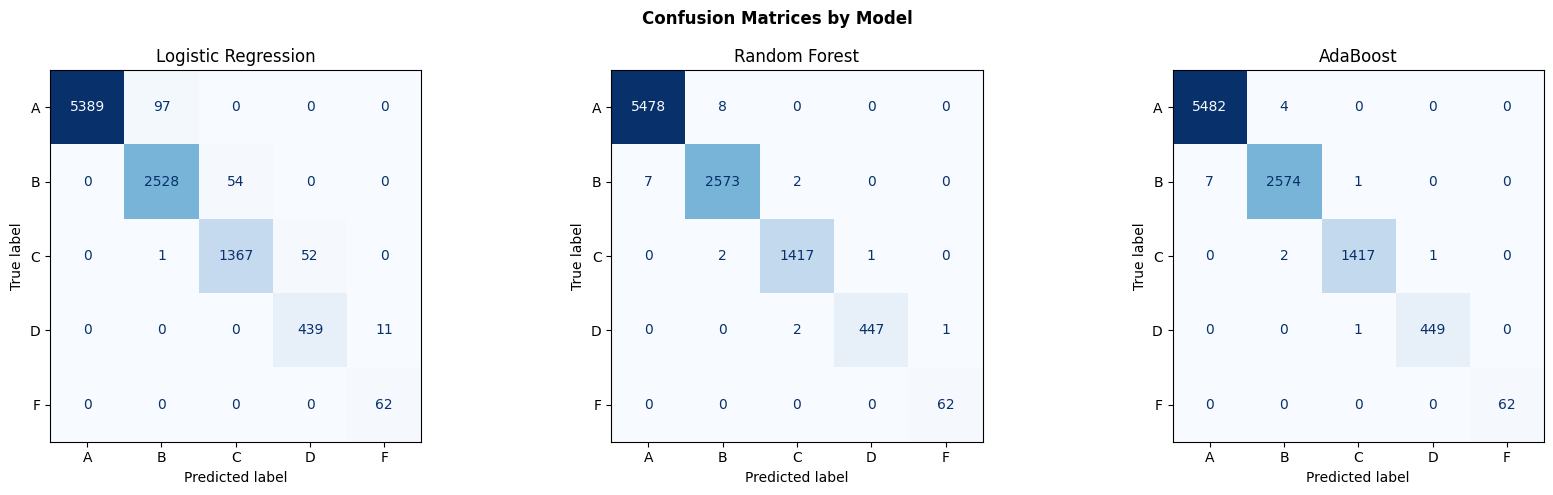


── Logistic Regression Confusion Matrix ──
[[5389   97    0    0    0]
 [   0 2528   54    0    0]
 [   0    1 1367   52    0]
 [   0    0    0  439   11]
 [   0    0    0    0   62]]

── Random Forest Confusion Matrix ──
[[5478    8    0    0    0]
 [   7 2573    2    0    0]
 [   0    2 1417    1    0]
 [   0    0    2  447    1]
 [   0    0    0    0   62]]

── AdaBoost Confusion Matrix ──
[[5482    4    0    0    0]
 [   7 2574    1    0    0]
 [   0    2 1417    1    0]
 [   0    0    1  449    0]
 [   0    0    0    0   62]]


In [139]:
# the confusion matrix shows exactly which grades the model is getting right and which ones it's confusing with each other
# this is more informative than just looking at accuracy

model_names = list(results.keys())
# plot all three confusion matrices side by side for easy comparison
fig, axes = plt.subplots(1, len(model_names), figsize=(17, 5))
fig.suptitle('Confusion Matrices by Model', fontweight='bold')
for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['preds'])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

# printing the raw confusion matrix numbers for the technical report
for name in model_names:
    print(f"\n── {name} Confusion Matrix ──")
    print(confusion_matrix(y_test, results[name]["preds"]))

# CROSS-VALIDATION

In [140]:
# instead of relying on one train/test split i'm using 5-fold CV
# this splits the data 5 different ways and averages the results so the scores are more reliable and not just lucky

cv_scores = {}
for name, model in models.items():
    Xall = X_train_sc if name == "Logistic Regression" else X_train
    scores = cross_val_score(model, Xall, y_train,
                             cv=5, scoring="f1_weighted", n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:25s}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV F1: 0.9801 ± 0.0020
Random Forest              CV F1: 0.9979 ± 0.0006
AdaBoost                   CV F1: 0.9981 ± 0.0003


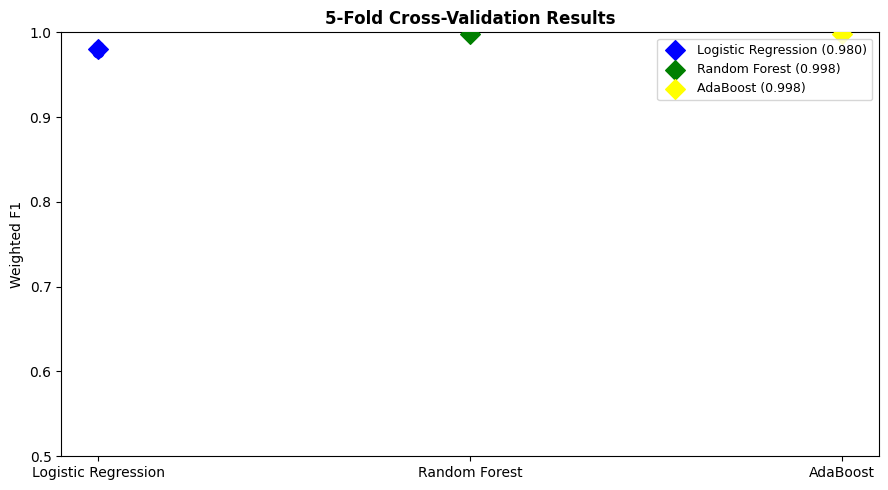

In [141]:
# visualize the spread of CV scores across all 5 folds
# diamond marker = mean, vertical line = ± 1 standard deviation
fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, scores) in enumerate(cv_scores.items()):
    ax.scatter([name]*len(scores), scores, color=PALETTE[i], zorder=3, s=60)
    ax.plot([name, name],
            [scores.mean()-scores.std(), scores.mean()+scores.std()],
            color=PALETTE[i], linewidth=2.5)
    ax.scatter([name], [scores.mean()], color=PALETTE[i], marker='D',
               s=100, zorder=4, label=f'{name} ({scores.mean():.3f})')
ax.set_ylabel('Weighted F1'); ax.set_ylim(0.5, 1.0)
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [142]:
# sweeping max_depth for Random Forest to see which value works best
# too shallow = model is too simple and misses patterns
# too deep = model overfits the training data


print("\n Random Forest max_depth sweep (5-fold CV F1)")
depths = [5, 8, 12, 20, None]
for depth in depths:
    m = RandomForestClassifier(
        n_estimators=200, max_depth=depth,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    s = cross_val_score(m, X_train, y_train, cv=5,
                        scoring="f1_weighted", n_jobs=-1)
    print(f"  max_depth={str(depth):5s}  {s.mean():.4f} ± {s.std():.4f}")


 Random Forest max_depth sweep (5-fold CV F1)
  max_depth=5      0.9980 ± 0.0005
  max_depth=8      0.9979 ± 0.0005
  max_depth=12     0.9979 ± 0.0006
  max_depth=20     0.9979 ± 0.0005
  max_depth=None   0.9979 ± 0.0005


## FEATURE IMPORTANCE

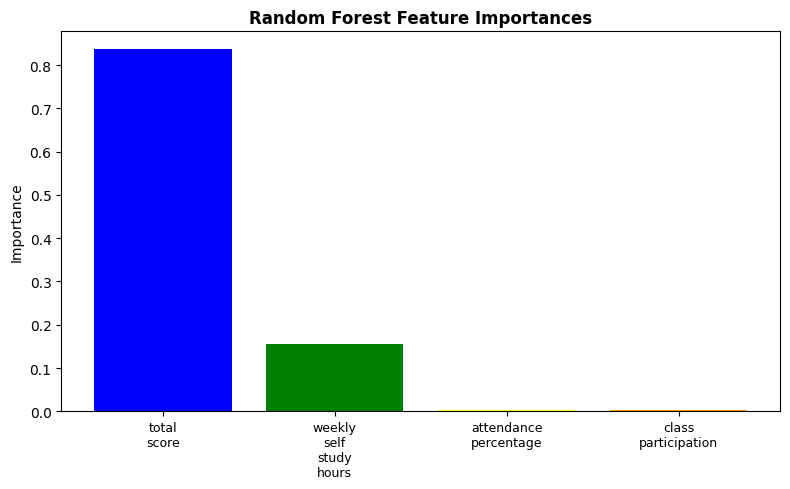

In [143]:
# Random Forest gives us feature importances directly
# this tells us which features the model relied on most

rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
# sort features from most to least important
idx = np.argsort(importances)[::-1]
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(features)), importances[idx], color=PALETTE[:len(features)])
ax.set_xticks(range(len(features)))
ax.set_xticklabels([features[i].replace('_', '\n') for i in idx], fontsize=9)
ax.set_title('Random Forest Feature Importances', fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

# MODEL COMPARISON FIGURE

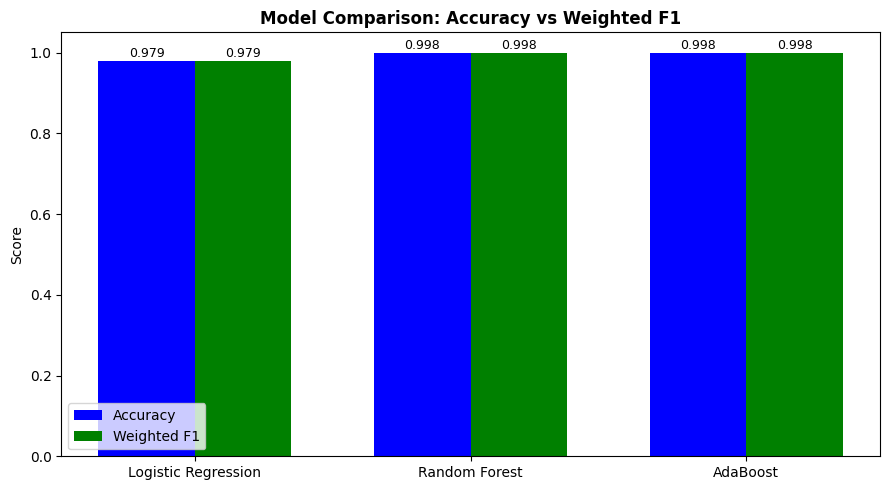

In [144]:
# side by side bar chart comparing accuracy and F1 for all models
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(model_names)); w = 0.35
b1 = ax.bar(x - w/2, [results[m]['accuracy'] for m in model_names],
            w, label='Accuracy', color=PALETTE[0])
b2 = ax.bar(x + w/2, [results[m]['f1'] for m in model_names],
            w, label='Weighted F1', color=PALETTE[1])
# add value labels on top of each bar
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy vs Weighted F1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()



# SUMMARY TABLE

In [145]:
summary = pd.DataFrame({
    "Model":     model_names,
    "Accuracy":  [f"{results[m]['accuracy']:.4f}"  for m in model_names],
    "Precision": [f"{results[m]['precision']:.4f}" for m in model_names],
    "Recall":    [f"{results[m]['recall']:.4f}"    for m in model_names],
    "F1":        [f"{results[m]['f1']:.4f}"        for m in model_names],
    "CV F1":     [f"{cv_scores[m].mean():.4f} ± {cv_scores[m].std():.4f}"
                  for m in model_names],
})
print("\nFinal Summary:")
print(summary.to_string(index=False))
 


Final Summary:
              Model Accuracy Precision Recall     F1           CV F1
Logistic Regression   0.9785    0.9793 0.9785 0.9787 0.9801 ± 0.0020
      Random Forest   0.9977    0.9977 0.9977 0.9977 0.9979 ± 0.0006
           AdaBoost   0.9984    0.9984 0.9984 0.9984 0.9981 ± 0.0003


# LIMITATIONS, ETHICS & REFLECTION

# Limitations:
# - total_score is likely dominating the prediction since grades
#   are directly calculated from it. the model might just be
#   learning the grading formula rather than actual behavior patterns
# - the dataset is synthetic so results may not reflect real schools
# - we sampled 50k rows for speed; training on all 1M might help
#   with the rare grades like F
#
# Ethics:
# - if this kind of model were used on real students it could
#   reinforce existing inequalities. students with less access
#   to resources might get labeled as "at risk" unfairly
# - predictions should be used to help students, not to make
#   decisions for them without human judgment involved
# - student data needs to be kept private even if anonymized
#
# References:
# - Dataset: student_performance.csv (Kaggle, synthetic)
# - scikit-learn, pandas, numpy, matplotlib, seaborn
# - AI assistance: Claude (Anthropic) used for code help throughout the project